<a href="https://colab.research.google.com/github/luizoquadros-lang/NLP_Zipfs_law_of_abbreviation/blob/main/PLN_Zipf's_law_of_abbreviation_task_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#NLP_Zipfs_law_of_abbreviation
#Authors: Luiz Quadros, Mengqi Liu and Nur Boada.

#We will start by importing the necessary packages for our task
import urllib.request
from datasets import load_dataset
import re
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
#First things first, we will start by importing a Poetry Dataset in English
english_dataset = load_dataset("merve/poetry")
#Now, we will join all the poems by deleting any spaces. Since they are in train/poem section, we will specify it. Also, we will lowercase all letters
english_poems = " ".join(english_dataset['train']['content']).lower()
#Finally, to get a list of words, we will quickly do so by using regex
english_words = re.findall(r"\b[a-z']*[a-z][a-z']*\b", english_poems)

README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


poetry.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/573 [00:00<?, ? examples/s]

In [ ]:
#If we print them out, we can see the list, by applying (len) we make sure that the number is large enough to contain the words in the poems
print(english_words)
len(english_words)

['let', 'the', 'bird', 'of', 'loudest', 'lay', 'on', 'the', 'sole', 'arabian', 'tree', 'herald', 'sad', 'and', 'trumpet', 'be', 'to', 'whose', 'sound', 'chaste', 'wings', 'obey', 'but', 'thou', 'shrieking', 'harbinger', 'foul', 'precurrer', 'of', 'the', 'fiend', 'augur', 'of', 'the', "fever's", 'end', 'to', 'this', 'troop', 'come', 'thou', 'not', 'near', 'from', 'this', 'session', 'interdict', 'every', 'fowl', 'of', 'tyrant', 'wing', 'save', 'the', 'eagle', "feather'd", 'king', 'keep', 'the', 'obsequy', 'so', 'strict', 'let', 'the', 'priest', 'in', 'surplice', 'white', 'that', 'defunctive', 'music', 'can', 'be', 'the', 'death', 'divining', 'swan', 'lest', 'the', 'requiem', 'lack', 'his', 'right', 'and', 'thou', 'treble', 'dated', 'crow', 'that', 'thy', 'sable', 'gender', "mak'st", 'with', 'the', 'breath', 'thou', "giv'st", 'and', "tak'st", 'mongst', 'our', 'mourners', 'shalt', 'thou', 'go', 'here', 'the', 'anthem', 'doth', 'commence', 'love', 'and', 'constancy', 'is', 'dead', 'phoenix'

99739

In [ ]:
#Now it's time for the Spanish dataset. We start by loading it
spanish_dataset = load_dataset("jorge-henao/disco_poetry_spanish")
#Then, we just do the same as we did with English
spanish_poems = " ".join(spanish_dataset['train']['text']).lower()
spanish_words = re.findall(r"\b[a-záéíóúüñ']+\b",spanish_poems)

Repo card metadata block was not found. Setting CardData to empty.


In [ ]:
#We run the same comprovations
print(spanish_words)
len(spanish_words)

['dónde', 'sansón', 'está', 'la', 'fortaleza', 'con', 'qué', 'heroico', 'la', 'fama', 'te', 'eterniza', 'dónde', 'la', 'ciencia', 'di', 'que', 'te', 'autoriza', 'escoger', 'salomón', 'a', 'tu', 'grandeza', 'dónde', 'david', 'oculta', 'tu', 'nobleza', 'aquella', 'santidad', 'que', 'te', 'entroniza', 'si', 'cuando', 'más', 'el', 'bronce', 'solemniza', 'os', 'desdora', 'el', 'borrón', 'de', 'la', 'pureza', 'mas', 'si', 'a', 'francisco', 'bien', 'he', 'contemplado', 'apagar', 'el', 'ardor', 'que', 'os', 'ha', 'vencido', 'con', 'el', 'bello', 'coral', 'que', 'ha', 'derramado', 'aun', 'más', 'triunfante', 'cuanto', 'más', 'dormido', 'en', 'él', 'para', 'su', 'gloria', 'aventajado', 'está', 'lo', 'fuerte', 'santo', 'y', 'entendido', 'cuando', 'en', 'horror', 'medroso', 'y', 'ciego', 'espanto', 'por', 'los', 'teucros', 'discurre', 'alecto', 'airada', 'y', 'el', 'impío', 'acero', 'de', 'la', 'griega', 'espada', 'hace', 'crecer', 'con', 'frigia', 'sangre', 'el', 'janto', 'entre', 'las', 'quejas'

399142

In [ ]:
#Now is time to calculate our most frequent words. We'll start (once again) with English
#First, we count each word
word_counts_English = Counter(english_words)
#We create our table with two columns: word and frequency
df_english = pd.DataFrame(word_counts_English.items(), columns=['word', 'frequency'])
#Now, to fully see the effects of Zipf's Law of Abbreviation, we need to check how long each word is. For that, we add a length column.
df_english['length'] = df_english['word'].apply(len)
#Now it is time to rank them and make them easier to interpret. To do so we will order by frequency and then, we will give them a new index and get rid of the one we had prior to ranking the words
df_english = df_english.sort_values(by='frequency', ascending=False).reset_index(drop=True)
#Finally, we assign a rank to each word. We use the method=min code to assign the same rank to words with the same frequency
df_english['rank'] = df_english['frequency'].rank(ascending=False, method='min').astype(int)
#To finish, let's print the whole thing
print (df_english)

                word  frequency  length  rank
0                the       4345       3     1
1                and       3587       3     2
2                 of       2195       2     3
3                 to       1972       2     4
4                 in       1586       2     5
...              ...        ...     ...   ...
11792  nightingale's          1      13  6350
11793       starting          1       8  6350
11794           frog          1       4  6350
11795    persistence          1      11  6350
11796        agelong          1       7  6350

[11797 rows x 4 columns]


In [ ]:
#Now, to make the Spanish one we follow the exact same steps, but changing everything where we typed English before for Spanish
word_counts_Spanish = Counter(spanish_words)
df_spanish = pd.DataFrame(word_counts_Spanish.items(), columns=['word', 'frequency'])
df_spanish['length'] = df_spanish['word'].apply(len)
df_spanish = df_spanish.sort_values(by='frequency', ascending=False).reset_index(drop=True)
df_spanish['rank'] = df_spanish['frequency'].rank(ascending=False, method='min').astype(int)
print(df_spanish)

             word  frequency  length   rank
0              de      17612       2      1
1               y      15310       1      2
2              la      14612       2      3
3              el      13734       2      4
4             que      12053       3      5
...           ...        ...     ...    ...
31866    leyentes          1       8  16265
31867   decretaba          1       9  16265
31868    voltaire          1       8  16265
31869  regenerada          1      10  16265
31870   tornadizo          1       9  16265

[31871 rows x 4 columns]


In [ ]:
#To see the Top 10 words of each language is very easy, we just ask for the 10 at the top. We can do this with any number in our rank
print("TOP 10 English Words")
print(df_english.head(10))
print()
print("TOP 10 Spanish Words")
print(df_spanish.head(10))

TOP 10 English Words
   word  frequency  length  rank
0   the       4345       3     1
1   and       3587       3     2
2    of       2195       2     3
3    to       1972       2     4
4    in       1586       2     5
5     a       1452       1     6
6  that       1439       4     7
7     i       1429       1     8
8    my       1093       2     9
9  with       1042       4    10

TOP 10 Spanish Words
  word  frequency  length  rank
0   de      17612       2     1
1    y      15310       1     2
2   la      14612       2     3
3   el      13734       2     4
4  que      12053       3     5
5   en      11252       2     6
6    a       6467       1     7
7   su       5020       2     8
8  del       4408       3     9
9   al       4137       2    10


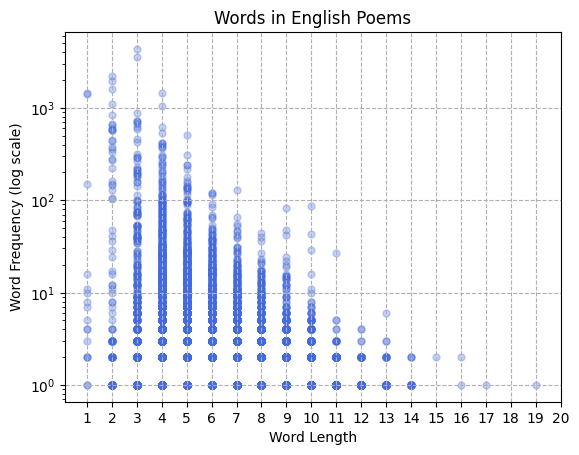

In [ ]:
plt.scatter(df_english['length'], df_english['frequency'], color='royalblue', s=25, alpha=0.5)
plt.yscale('log')
plt.xticks(range(1, 21))
plt.title("Words in English Poems")
plt.xlabel("Word Length")
plt.ylabel("Word Frequency (log scale)")
plt.grid(True, linestyle='--')
plt.show()

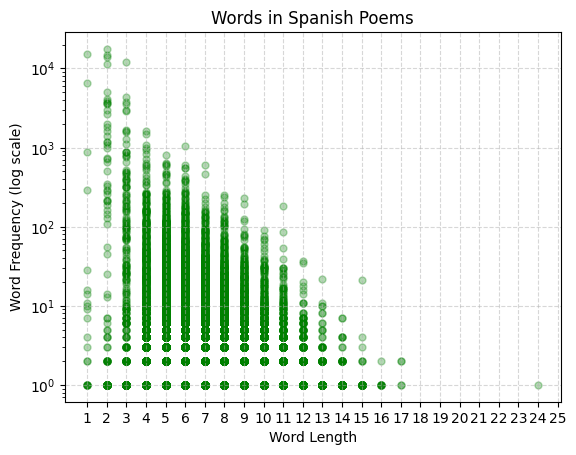

In [ ]:
plt.scatter(df_spanish['length'], df_spanish['frequency'], color='green', s=25, alpha=0.3)
plt.yscale('log')
plt.xticks(range(1, 26))
plt.title("Words in Spanish Poems")
plt.xlabel("Word Length")
plt.ylabel("Word Frequency (log scale)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()